## Install Library

In [6]:
# Install YOLOv8
!pip install ultralytics -q

# Cek versi
from ultralytics import YOLO

print("YOLOv8 berhasil diinstall")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 27.5 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
YOLOv8 berhasil diinstall


## Upload Kaggle API

In [7]:
from google.colab import files

files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"kknkrnwn11","key":"1f3ee2536cc23487b43abc66e68f5319"}'}

## Konfigurasi Kaggle

In [8]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

## Download Dataset

In [9]:
!kaggle datasets download -d abtinzandi/obstacle-detection-dataset

Dataset URL: https://www.kaggle.com/datasets/abtinzandi/obstacle-detection-dataset
License(s): MIT
100% 1.41G/1.41G [00:14<00:00, 108MB/s]



## Ekstrak Dataset

In [10]:
import zipfile

zip_path = "obstacle-detection-dataset.zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("dataset")

print("Dataset berhasil diekstrak")

Dataset berhasil diekstrak


In [13]:
import os

for root, dirs, files in os.walk('/content/dataset'):
    print(root)

/content/dataset
/content/dataset/ROD-Dataset
/content/dataset/ROD-Dataset/dataset
/content/dataset/ROD-Dataset/dataset/test
/content/dataset/ROD-Dataset/dataset/test/labels
/content/dataset/ROD-Dataset/dataset/test/images
/content/dataset/ROD-Dataset/dataset/valid
/content/dataset/ROD-Dataset/dataset/valid/labels
/content/dataset/ROD-Dataset/dataset/valid/images
/content/dataset/ROD-Dataset/dataset/train
/content/dataset/ROD-Dataset/dataset/train/labels
/content/dataset/ROD-Dataset/dataset/train/images


In [14]:
import os

os.listdir('/content/dataset')

['citations.txt', 'citation_kaggle.md', 'ROD-Dataset']

## Lihat File data.yaml

In [15]:
!find /content/dataset -name "*.yaml"

/content/dataset/ROD-Dataset/dataset/data.yaml


In [16]:
with open('/content/dataset/ROD-Dataset/dataset/data.yaml', 'r') as f:
    print(f.read())

train: ../train/images
val: ../valid/images
test: ../test/images

nc: 25
names: ['Bike', 'Building', 'Car', 'Person', 'Stairs', 'Traffic sign', 'Electrical Pole', 'Road', 'Motorcycle', 'Dustbin', 'Dog', 'Manhole', 'Tree','Guard rail','Pedestrian crosswalk','Truck','Bus','Bench', 'Traffic Cone', 'Fire hydrant', 'Teraffic Barrel', 'Plant Pot', 'Electrical Box', 'Chair', 'Bicycle Rack']


## Verifikasi Struktur Dataset

In [17]:
import os

print("Train Images:", len(os.listdir('/content/dataset/ROD-Dataset/dataset/train/images')))
print("Train Labels:", len(os.listdir('/content/dataset/ROD-Dataset/dataset/train/labels')))

print("Valid Images:", len(os.listdir('/content/dataset/ROD-Dataset/dataset/valid/images')))
print("Valid Labels:", len(os.listdir('/content/dataset/ROD-Dataset/dataset/valid/labels')))

print("Test Images:", len(os.listdir('/content/dataset/ROD-Dataset/dataset/test/images')))
print("Test Labels:", len(os.listdir('/content/dataset/ROD-Dataset/dataset/test/labels')))

Train Images: 19186
Train Labels: 19186
Valid Images: 3511
Valid Labels: 3511
Test Images: 1629
Test Labels: 1629


In [18]:
import os

folders = [
    "/content/dataset/ROD-Dataset/dataset/train/images",
    "/content/dataset/ROD-Dataset/dataset/train/labels",
    "/content/dataset/ROD-Dataset/dataset/valid/images",
    "/content/dataset/ROD-Dataset/dataset/valid/labels",
    "/content/dataset/ROD-Dataset/dataset/test/images",
    "/content/dataset/ROD-Dataset/dataset/test/labels"
]

for folder in folders:
    print(folder, os.path.exists(folder))

/content/dataset/ROD-Dataset/dataset/train/images True
/content/dataset/ROD-Dataset/dataset/train/labels True
/content/dataset/ROD-Dataset/dataset/valid/images True
/content/dataset/ROD-Dataset/dataset/valid/labels True
/content/dataset/ROD-Dataset/dataset/test/images True
/content/dataset/ROD-Dataset/dataset/test/labels True


In [19]:
import os

train_images = len(os.listdir('/content/dataset/ROD-Dataset/dataset/train/images'))
valid_images = len(os.listdir('/content/dataset/ROD-Dataset/dataset/valid/images'))
test_images  = len(os.listdir('/content/dataset/ROD-Dataset/dataset/test/images'))

print("Train :", train_images)
print("Valid :", valid_images)
print("Test  :", test_images)

Train : 19186
Valid : 3511
Test  : 1629


## Pemeriksaan Missing Label

In [20]:
import os

image_dir = "/content/dataset/ROD-Dataset/dataset/train/images"
label_dir = "/content/dataset/ROD-Dataset/dataset/train/labels"

missing = []

for image in os.listdir(image_dir):

    txt_file = image.rsplit('.',1)[0] + ".txt"

    if not os.path.exists(
        os.path.join(label_dir, txt_file)
    ):
        missing.append(image)

print("Jumlah Missing Label :", len(missing))

Jumlah Missing Label : 0


## Pemeriksaan Label Kosong

In [21]:
empty_labels = []

for file in os.listdir(label_dir):

    path = os.path.join(label_dir,file)

    if os.path.getsize(path) == 0:
        empty_labels.append(file)

print("Label kosong :", len(empty_labels))

Label kosong : 83


## Analisis Distribusi Kelas

In [22]:
from collections import Counter
import os

counter = Counter()

for file in os.listdir(label_dir):

    with open(os.path.join(label_dir,file),'r') as f:

        for line in f:

            class_id = int(line.split()[0])

            counter[class_id] += 1

print(counter)

Counter({3: 7609, 2: 4328, 14: 1875, 11: 1779, 23: 1757, 12: 1632, 13: 1385, 9: 1351, 4: 1125, 16: 1009, 8: 888, 1: 886, 17: 706, 5: 689, 18: 678, 10: 633, 15: 621, 7: 561, 21: 560, 20: 540, 6: 491, 22: 450, 0: 323, 19: 205, 24: 170})


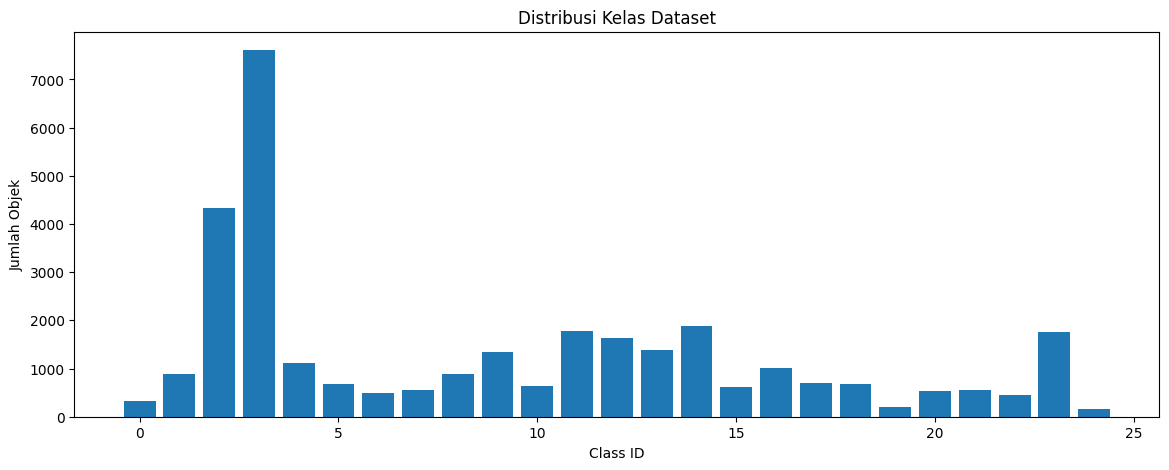

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,5))

plt.bar(counter.keys(), counter.values())

plt.xlabel("Class ID")
plt.ylabel("Jumlah Objek")
plt.title("Distribusi Kelas Dataset")

plt.show()

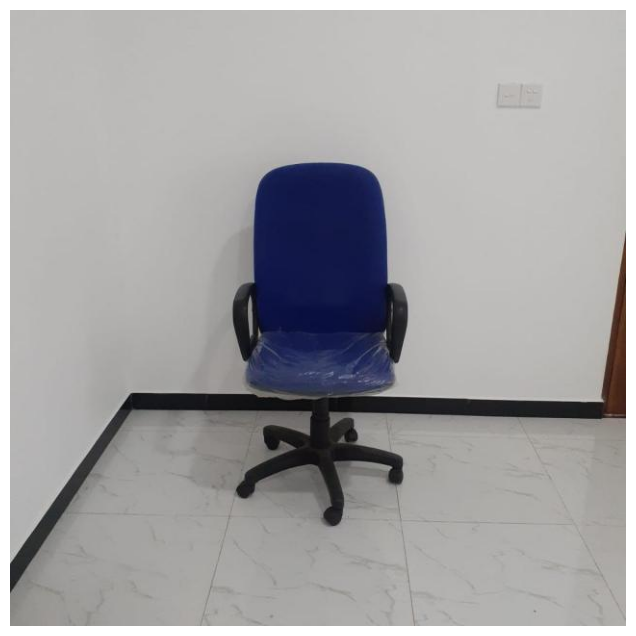

In [24]:
import cv2
import matplotlib.pyplot as plt
import random
import os

image_dir = "/content/dataset/ROD-Dataset/dataset/train/images"

sample = random.choice(
    os.listdir(image_dir)
)

img = cv2.imread(
    os.path.join(image_dir,sample)
)

img = cv2.cvtColor(
    img,
    cv2.COLOR_BGR2RGB
)

plt.figure(figsize=(8,8))
plt.imshow(img)
plt.axis("off")
plt.show()

## Install YOLOv8

In [25]:
!pip install ultralytics -q

In [26]:
from ultralytics import YOLO

In [27]:
model = YOLO("yolov8n.pt")

## Training Model

In [28]:
results = model.train(
    data='/content/dataset/ROD-Dataset/dataset/data.yaml',
    epochs=50,
    imgsz=640,
    batch=16,
    workers=2,
    patience=10,
    device=0,
    project='ObstacleDetection',
    name='YOLOv8n'
)

Ultralytics 8.4.67 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset/ROD-Dataset/dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=YOLOv8n, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=Tru

## Monitoring Training

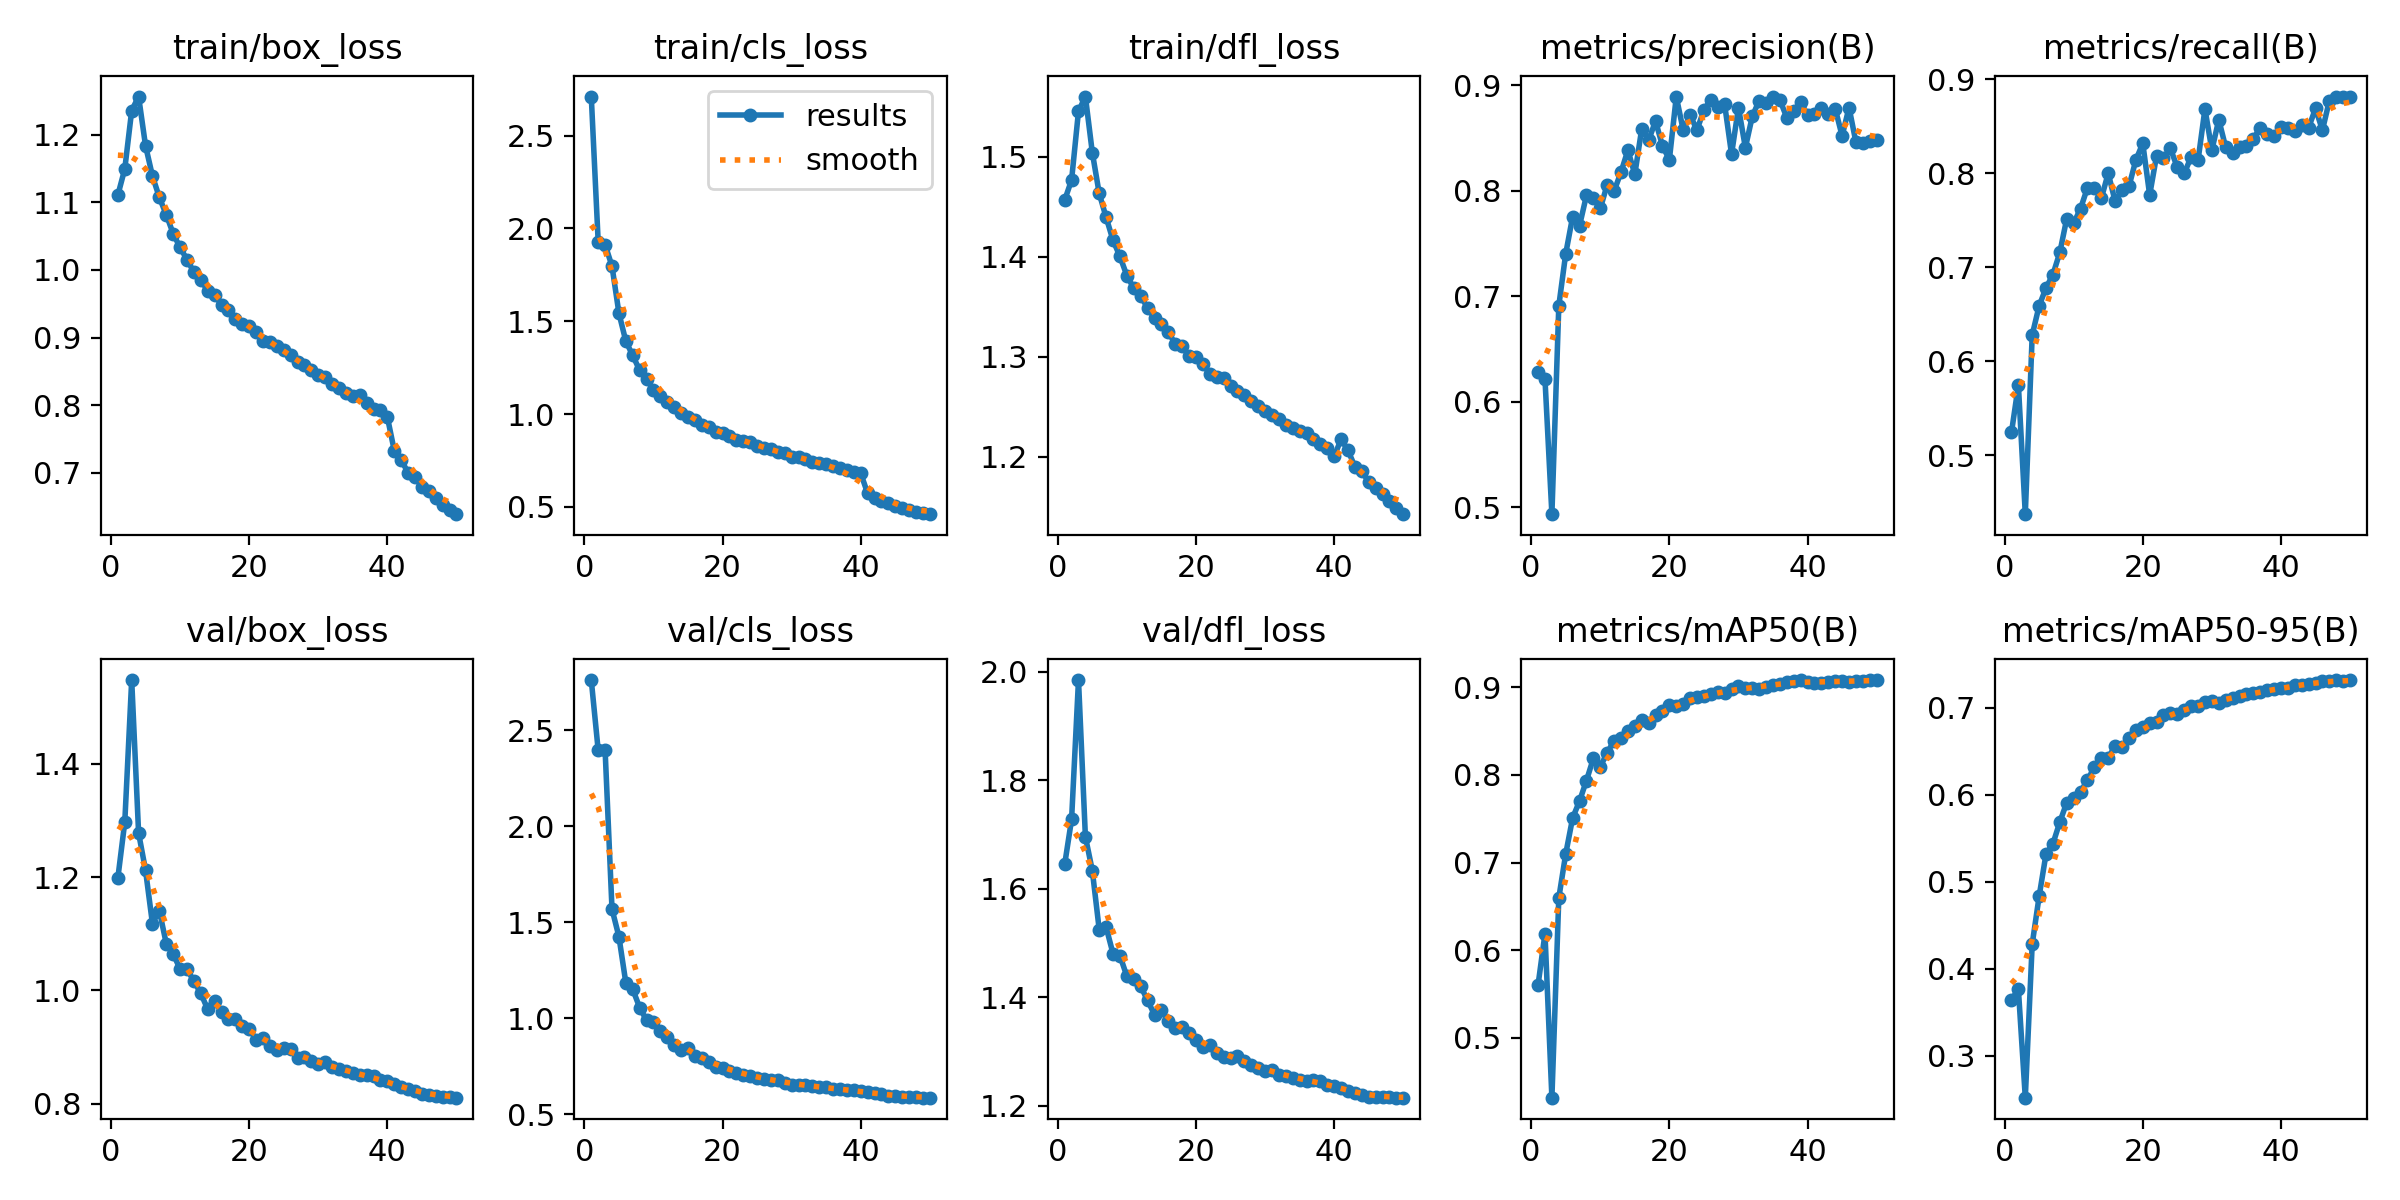

In [30]:
from IPython.display import Image

Image(
    '/content/runs/detect/ObstacleDetection/YOLOv8n/results.png'
)

## Evaluasi Model

In [31]:
metrics = model.val()

print(metrics)

Ultralytics 8.4.67 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,010,523 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1158.4±507.6 MB/s, size: 34.3 KB)
val: Scanning /content/dataset/ROD-Dataset/dataset/valid/labels.cache... 3511 images, 11 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 3511/3511 1.2Git/s 0.0s
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 821, len(boxes) = 5572. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 220/220 6.6it/s 33.2s
                   all       3511       5572      0.845      0.882      0.908      0.732
                  Bike         88         95          1      0.903      0.963      0.828
              Bui

## Confusion Matrix

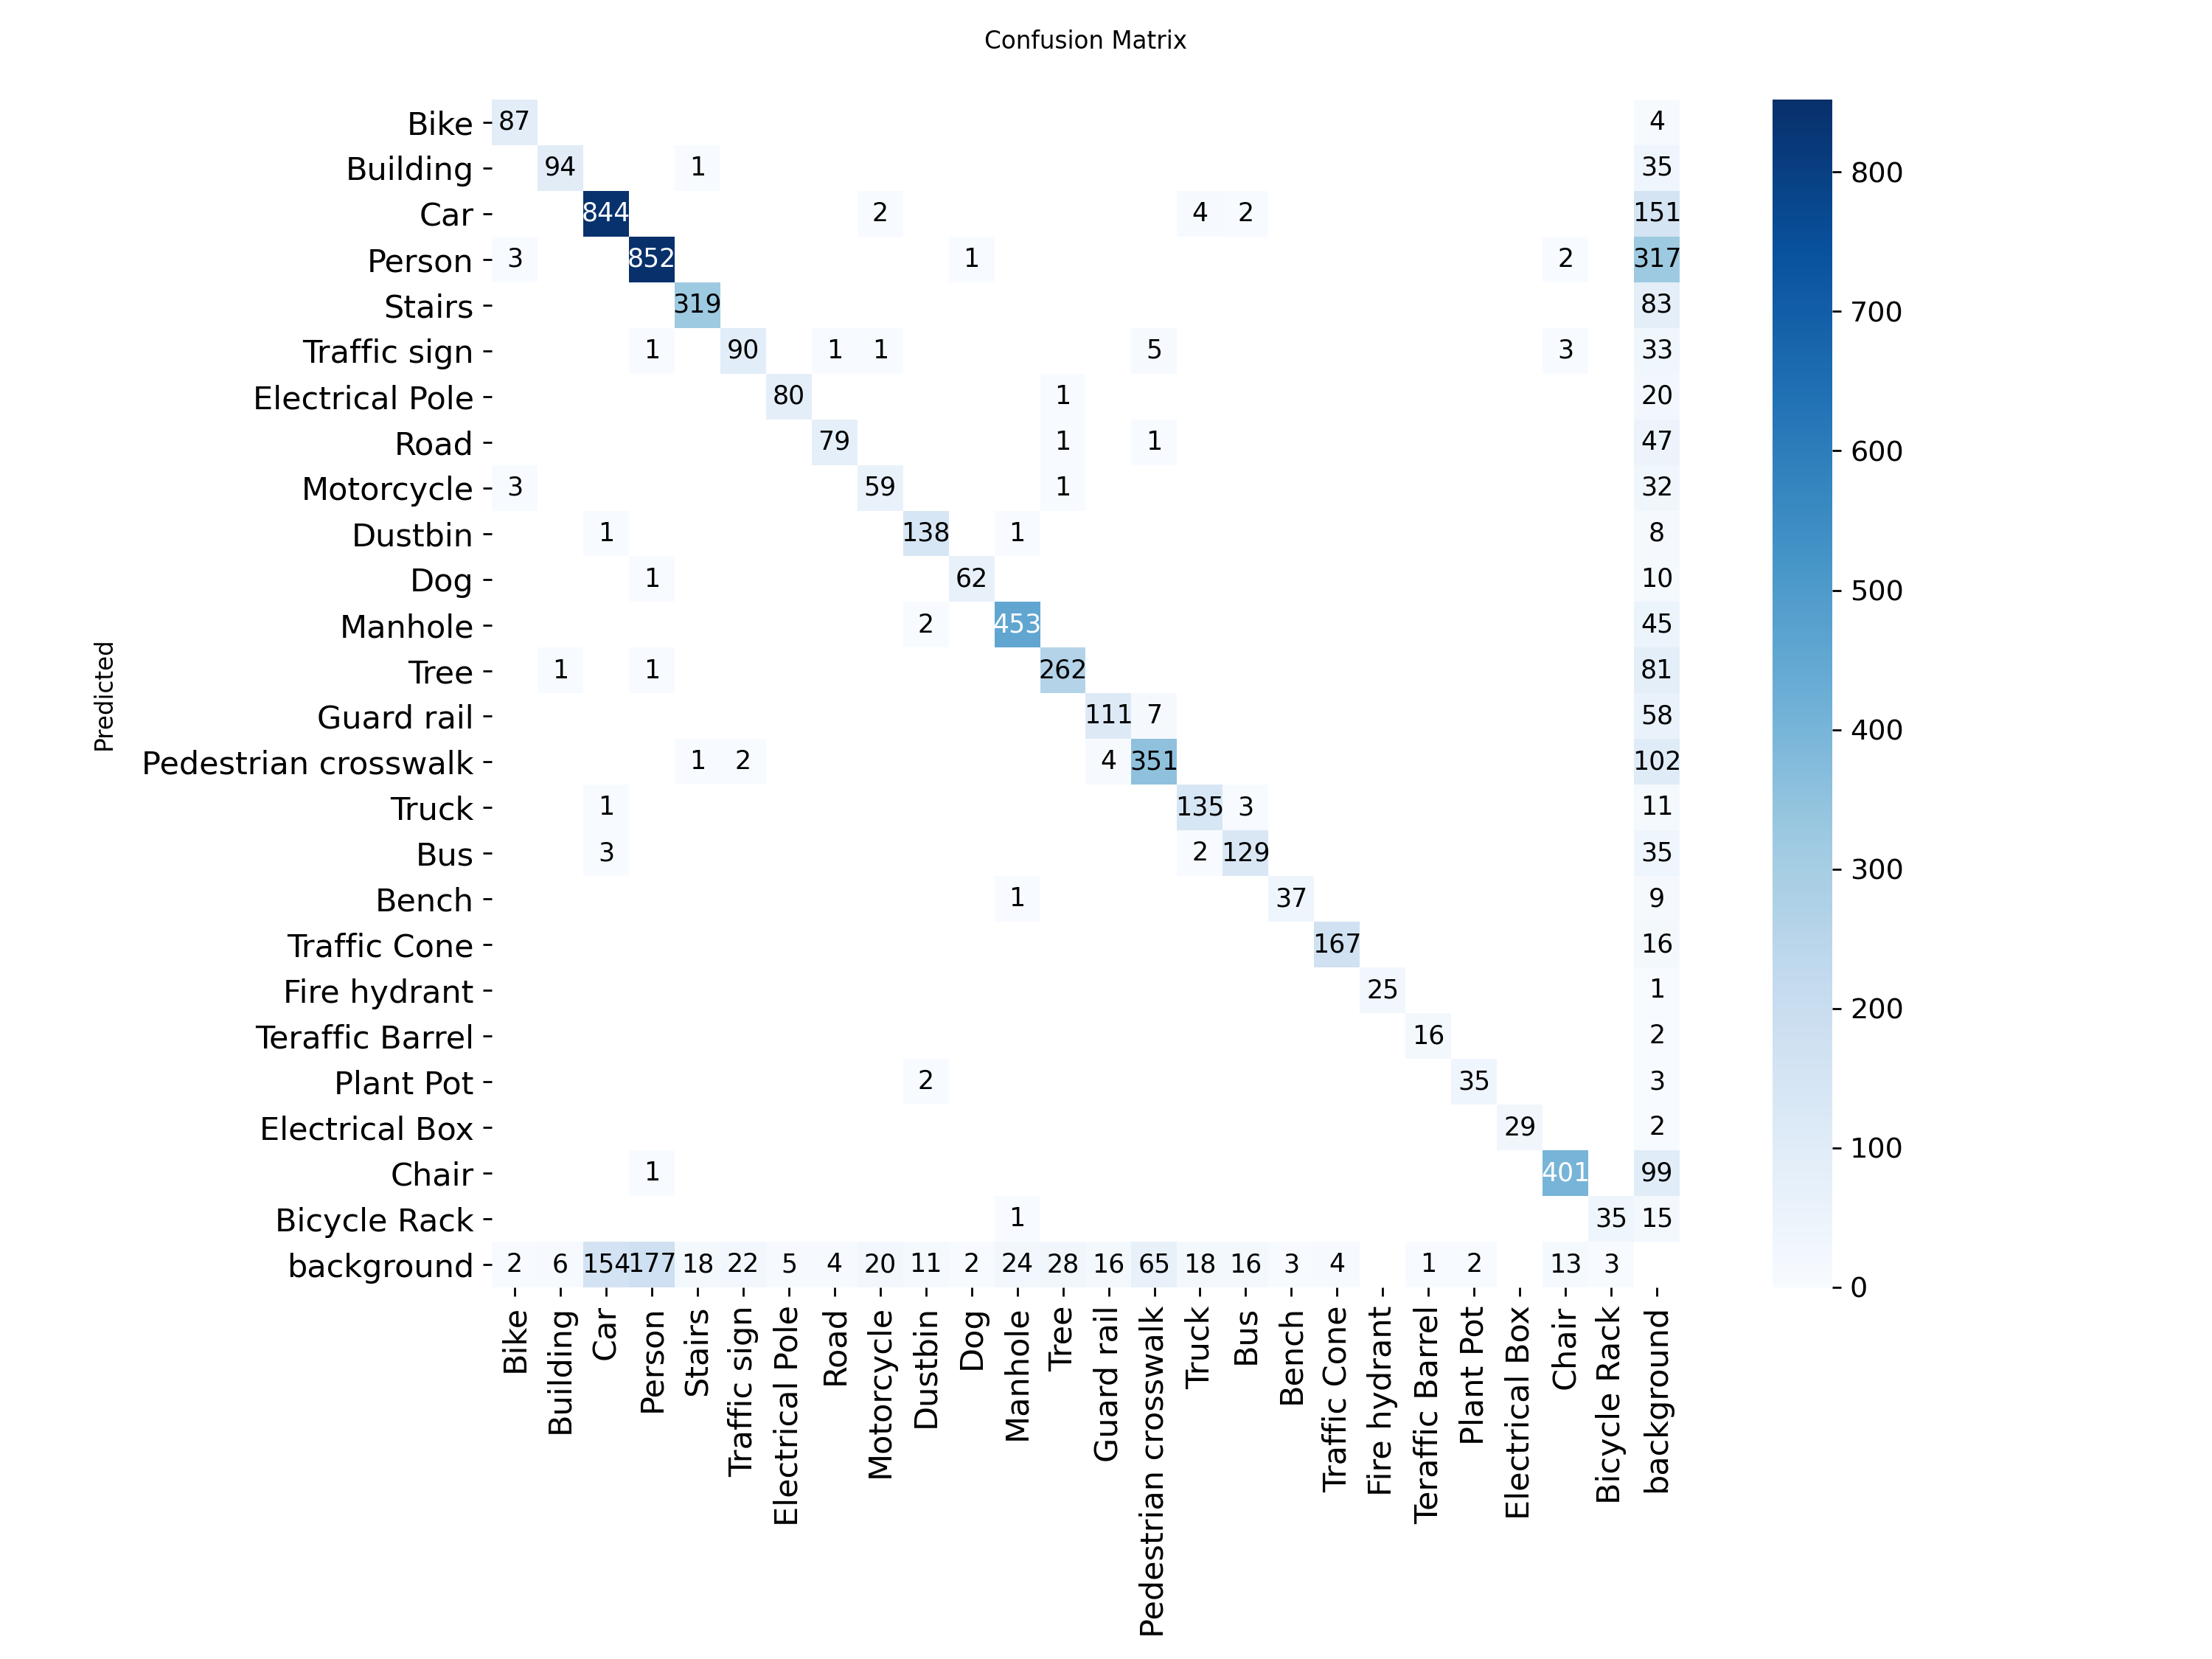

In [33]:
Image(
    '/content/runs/detect/ObstacleDetection/YOLOv8n/confusion_matrix.png'
)

## Prediksi Data Test

In [34]:
model.predict(
    source='/content/dataset/ROD-Dataset/dataset/test/images',
    save=True,
    conf=0.25
)


WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

image 1/1629 /content/dataset/ROD-Dataset/dataset/test/images/IMG_19187.jpg: 640x640 1 Car, 7.6ms
image 2/1629 /content/dataset/ROD-Dataset/dataset/test/images/IMG_19188.jpg: 640x640 1 Manhole, 7.2ms
image 3/1629 /content/dataset/ROD-Dataset/dataset/test/images/IMG_19189.jpg: 640x640 1 Car, 7.2ms
image 4/1629 /content/dataset/ROD-Dataset/dataset/test/images/IMG_19190.jpg: 640x640 1 Car, 7.3ms
image 5/1629 /content/dataset/ROD-Dataset/dataset/test/images/

[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'Bike', 1: 'Building', 2: 'Car', 3: 'Person', 4: 'Stairs', 5: 'Traffic sign', 6: 'Electrical Pole', 7: 'Road', 8: 'Motorcycle', 9: 'Dustbin', 10: 'Dog', 11: 'Manhole', 12: 'Tree', 13: 'Guard rail', 14: 'Pedestrian crosswalk', 15: 'Truck', 16: 'Bus', 17: 'Bench', 18: 'Traffic Cone', 19: 'Fire hydrant', 20: 'Teraffic Barrel', 21: 'Plant Pot', 22: 'Electrical Box', 23: 'Chair', 24: 'Bicycle Rack'}
 obb: None
 orig_img: array([[[ 59,  60,  56],
         [ 59,  60,  56],
         [ 60,  61,  59],
         ...,
         [ 53,  55,  55],
         [ 52,  57,  56],
         [ 51,  56,  55]],
 
        [[ 59,  60,  56],
         [ 59,  60,  56],
         [ 60,  61,  59],
         ...,
         [ 55,  57,  57],
         [ 52,  57,  56],
         [ 50,  55,  54]],
 
        [[ 59,  60,  56],
         [ 59,  60,  56],
         [ 60,  61,  59],
     

## Hasil Prediksi

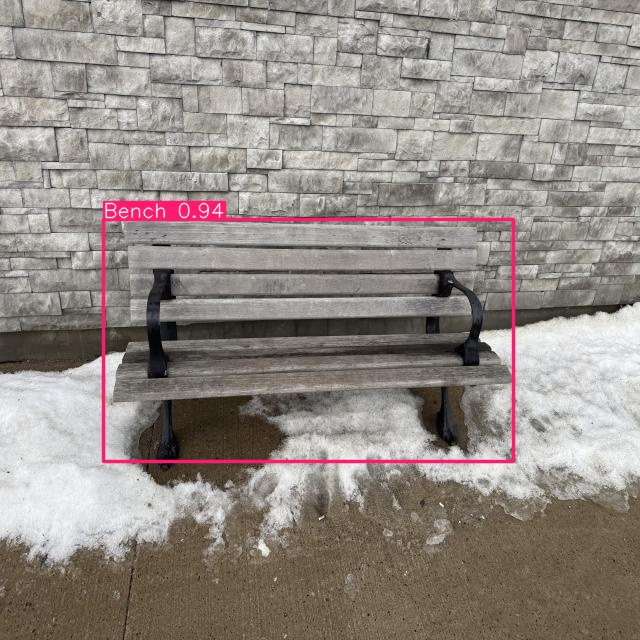

In [35]:
import glob
from IPython.display import Image

preds = glob.glob(
    '/content/runs/detect/predict/*.jpg'
)

Image(preds[0])

## Model Terbaik

In [37]:
from google.colab import files

files.download(
'/content/runs/detect/ObstacleDetection/YOLOv8n/weights/best.pt'
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Evaluasi

In [38]:
metrics = model.val()

print("mAP50 :", metrics.box.map50)
print("mAP50-95 :", metrics.box.map)

Ultralytics 8.4.67 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 876.9±308.1 MB/s, size: 62.3 KB)
val: Scanning /content/dataset/ROD-Dataset/dataset/valid/labels.cache... 3511 images, 11 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 3511/3511 775.1Mit/s 0.0s
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 821, len(boxes) = 5572. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 220/220 6.5it/s 34.0s
                   all       3511       5572      0.845      0.882      0.908      0.732
                  Bike         88         95          1      0.903      0.963      0.828
              Building         95        101      0.786      0.909      0.871      0.688
       

In [40]:
print("Final Model Evaluation Summary:")
print(f"Precision (Box): {metrics.results_dict['metrics/precision(B)']:.4f}")
print(f"Recall (Box): {metrics.results_dict['metrics/recall(B)']:.4f}")
print(f"mAP50 (Box): {metrics.box.map50:.4f}")
print(f"mAP50-95 (Box): {metrics.box.map:.4f}")

Final Model Evaluation Summary:
Precision (Box): 0.8448
Recall (Box): 0.8822
mAP50 (Box): 0.9077
mAP50-95 (Box): 0.7318
